Using device: cuda


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 208kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.88MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.9MB/s]


Visualizing 5 samples per class for Data Understanding...


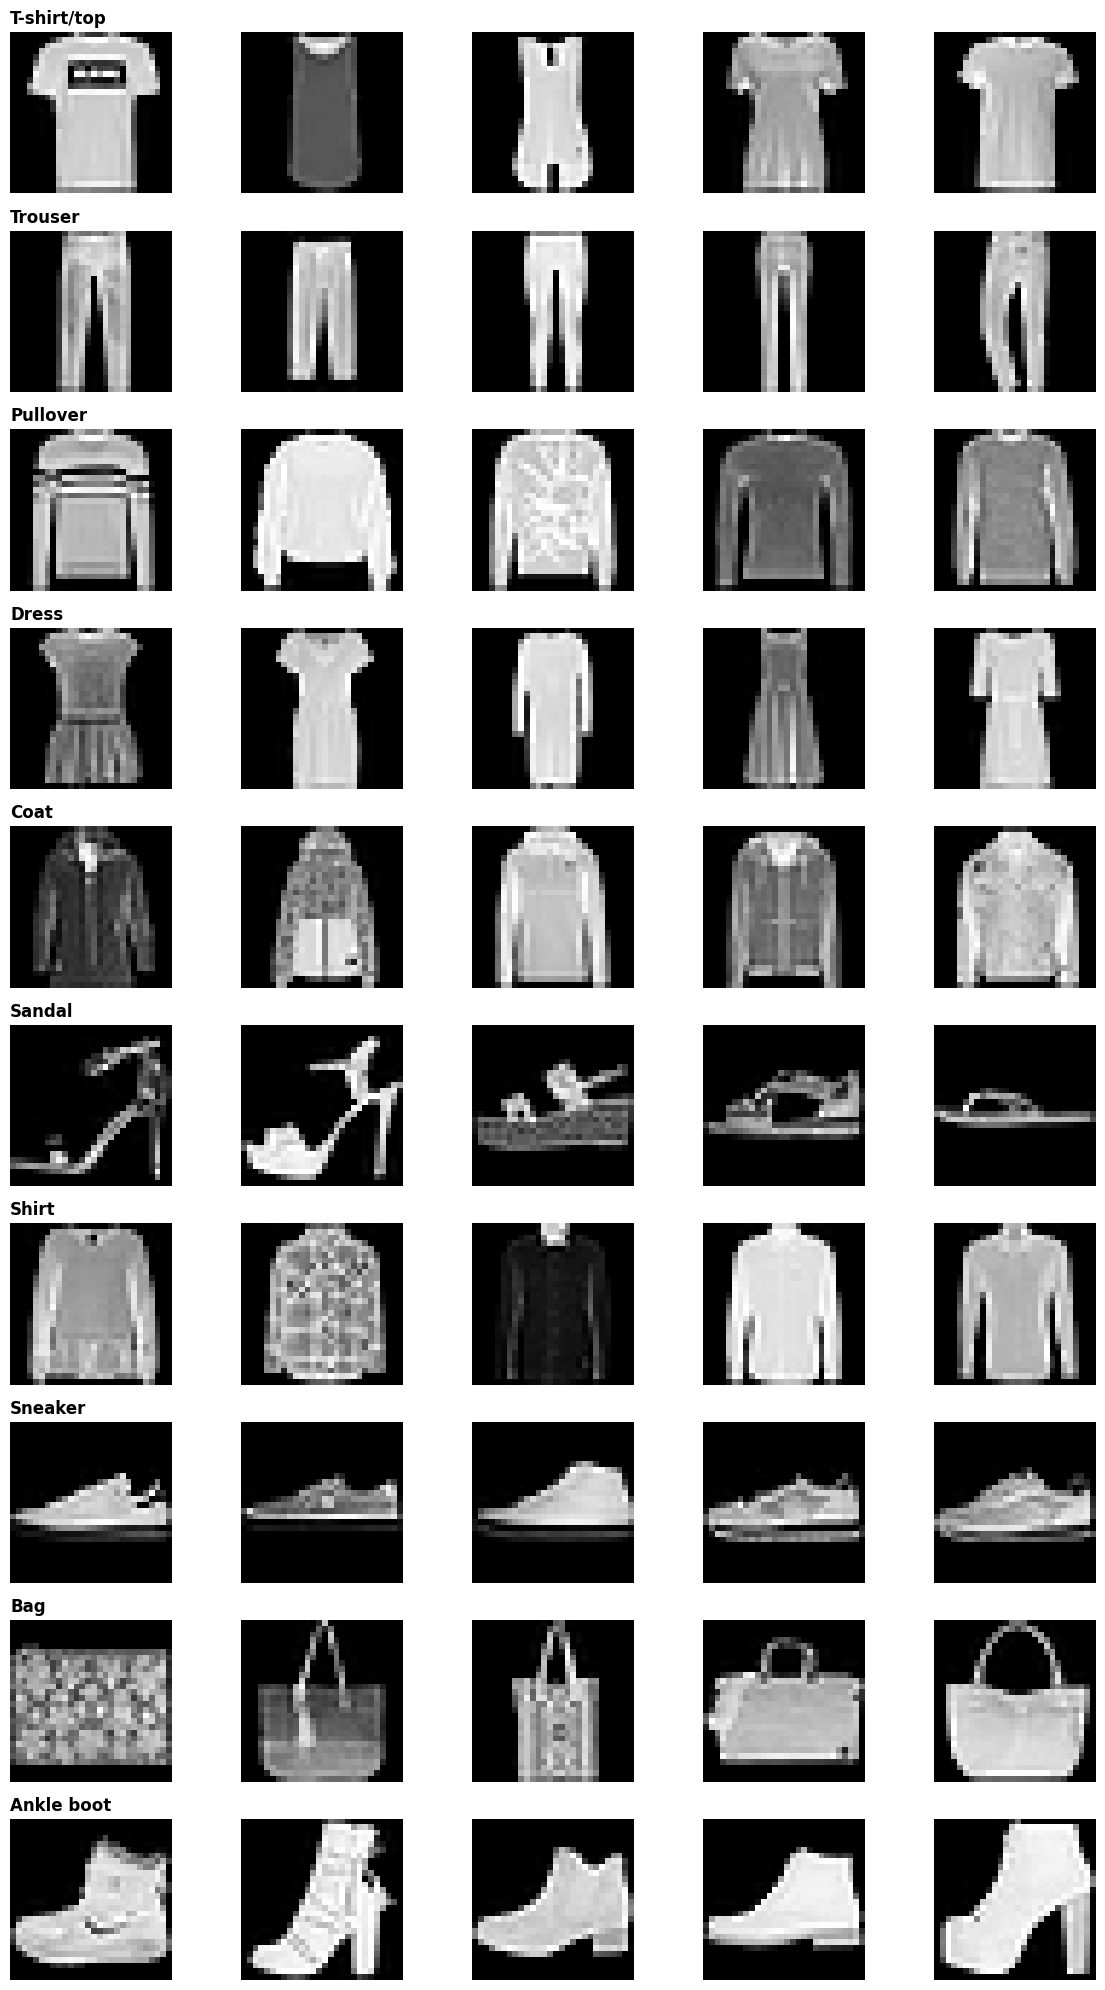

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=256, shuffle=False)

classes = train_dataset.classes

# 3. Visual Inspection: 5 Images Per Class (Task 1)
def show_five_per_class(dataset):
    # Dictionary to store 5 images for each of the 10 classes
    class_samples = {i: [] for i in range(10)}
    
    # Iterate through dataset to find 5 samples per class
    for img, label in dataset:
        if len(class_samples[label]) < 5:
            class_samples[label].append(img)
        
        # Stop once we have 5 samples for all 10 classes
        if all(len(samples) == 5 for samples in class_samples.values()):
            break

    # Plotting the 10x5 grid
    fig, axes = plt.subplots(10, 5, figsize=(12, 20))
    for label in range(10):
        for i in range(5):
            img = class_samples[label][i]
            axes[label, i].imshow(img.squeeze(), cmap='gray')
            axes[label, i].axis('off')
            if i == 0:
                axes[label, i].set_title(classes[label], loc='left', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

print("Visualizing 5 samples per class for Data Understanding...")
show_five_per_class(train_dataset)

In [2]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()
        
        # Encoder: 784 (28x28) -> 256 -> 128 -> latent_dim
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        
        # Decoder: latent_dim -> 128 -> 256 -> 784 (28x28)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid() # Squashes output back to [0, 1] for image pixels
        )

    def forward(self, x):
        z = self.encoder(x)
        reconstructed = self.decoder(z)
        return reconstructed.view(-1, 1, 28, 28), z


--- Training Small (Undercomplete) Model (Latent Size: 4) ---
Epoch [5/15], Loss: 0.0211
Epoch [10/15], Loss: 0.0196
Epoch [15/15], Loss: 0.0189

--- Training Medium (Balanced) Model (Latent Size: 32) ---
Epoch [5/15], Loss: 0.0169
Epoch [10/15], Loss: 0.0136
Epoch [15/15], Loss: 0.0122

--- Training Large (Overcomplete) Model (Latent Size: 128) ---
Epoch [5/15], Loss: 0.0173
Epoch [10/15], Loss: 0.0137
Epoch [15/15], Loss: 0.0119


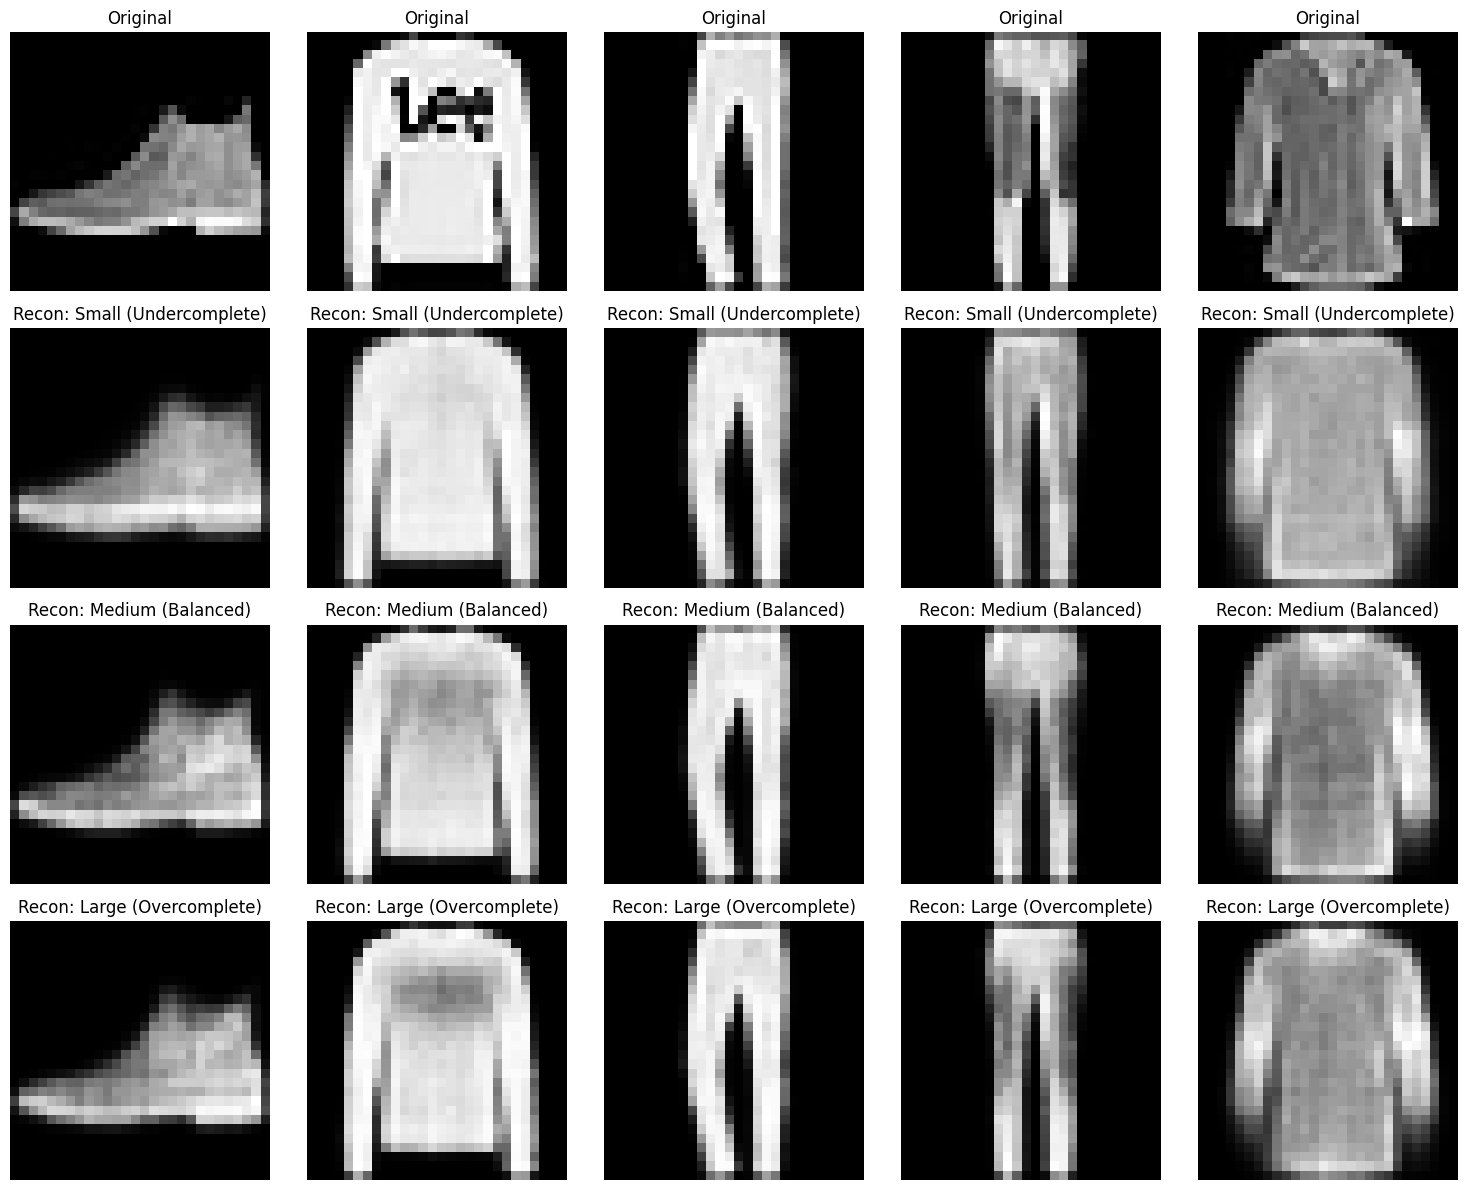

In [3]:
# Task 2 & 3: Train 3 models with different bottleneck sizes
latent_sizes = {
    "Small (Undercomplete)": 4,  # Forces compression
    "Medium (Balanced)": 32,
    "Large (Overcomplete)": 128  # Allows memorization
}

models = {}
epochs = 15 # Keep it relatively low for quick Kaggle iteration
criterion = nn.MSELoss()

for name, size in latent_sizes.items():
    print(f"\n--- Training {name} Model (Latent Size: {size}) ---")
    model = Autoencoder(latent_dim=size).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for images, _ in train_loader:
            images = images.to(device)
            optimizer.zero_grad()
            outputs, _ = model(images)
            loss = criterion(outputs, images)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        if (epoch+1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_loss/len(train_loader):.4f}")
            
    models[name] = model

# Reconstruction Visualization
def visualize_reconstructions(models, test_loader, num_images=5):
    images, _ = next(iter(test_loader))
    images = images[:num_images].to(device)
    
    fig, axes = plt.subplots(len(models) + 1, num_images, figsize=(15, 3 * (len(models) + 1)))
    
    # Plot Original
    for i in range(num_images):
        axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
        axes[0, i].set_title("Original")
        axes[0, i].axis('off')
        
    # Plot Reconstructions
    row = 1
    for name, model in models.items():
        model.eval()
        with torch.no_grad():
            recons, _ = model(images)
        for i in range(num_images):
            axes[row, i].imshow(recons[i].cpu().squeeze(), cmap='gray')
            axes[row, i].set_title(f"Recon: {name}")
            axes[row, i].axis('off')
        row += 1
    plt.tight_layout()
    plt.show()

visualize_reconstructions(models, test_loader)

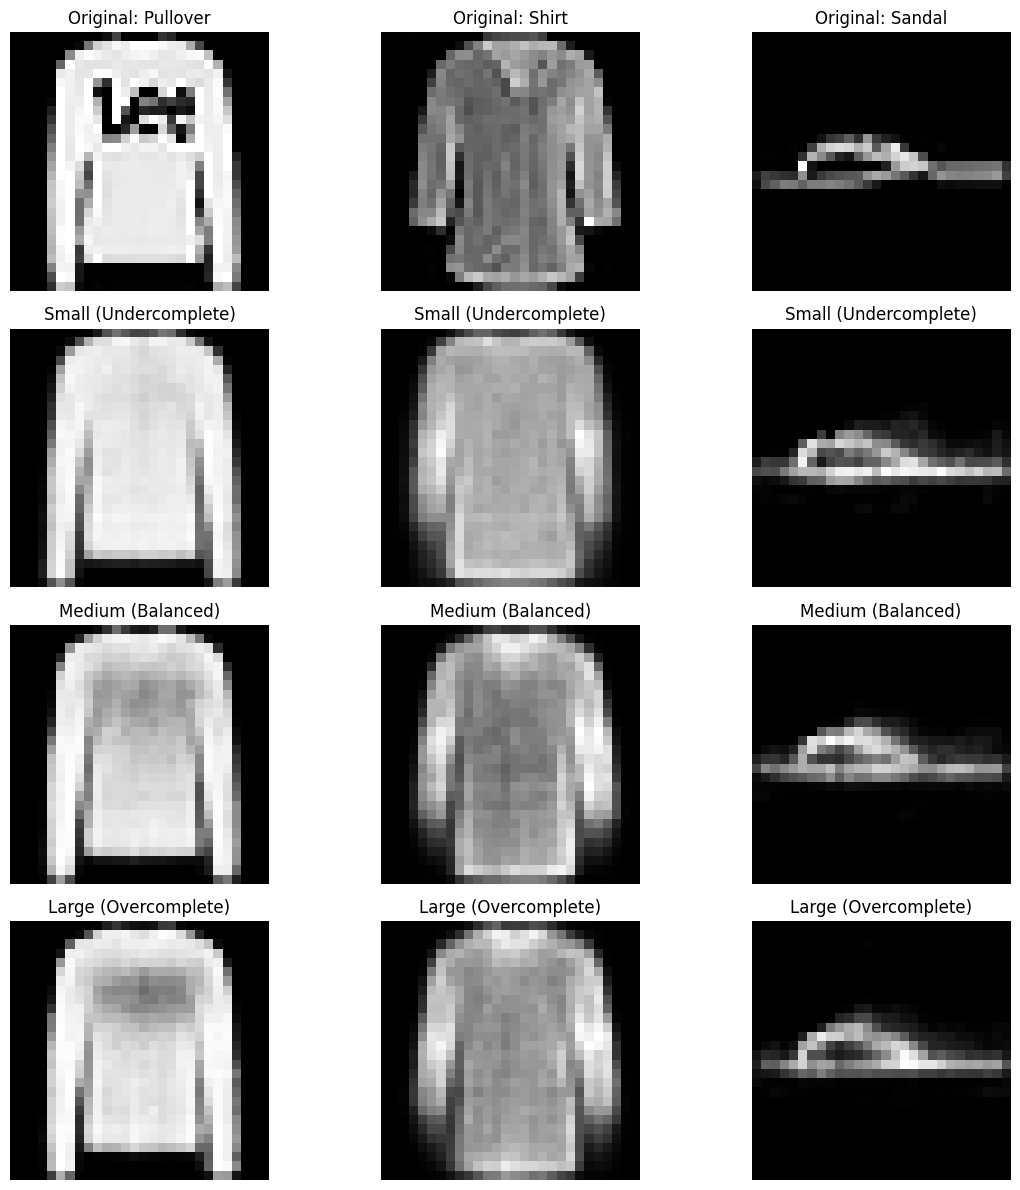

In [4]:
def visualize_edge_cases(models, dataset):
    target_indices = [1, 4, 8] 
    
    fig, axes = plt.subplots(len(models) + 1, len(target_indices), figsize=(12, 12))
    
    for col, idx in enumerate(target_indices):
        img, label = dataset[idx]
        img_input = img.unsqueeze(0).to(device)
        
        # Original
        axes[0, col].imshow(img.squeeze(), cmap='gray')
        axes[0, col].set_title(f"Original: {classes[label]}")
        axes[0, col].axis('off')
        
        # Reconstructions
        for row, (name, model) in enumerate(models.items()):
            model.eval()
            with torch.no_grad():
                recon, _ = model(img_input)
            axes[row+1, col].imshow(recon.cpu().squeeze(), cmap='gray')
            axes[row+1, col].set_title(f"{name}")
            axes[row+1, col].axis('off')
            
    plt.tight_layout()
    plt.show()

visualize_edge_cases(models, test_dataset)

Computing PCA...


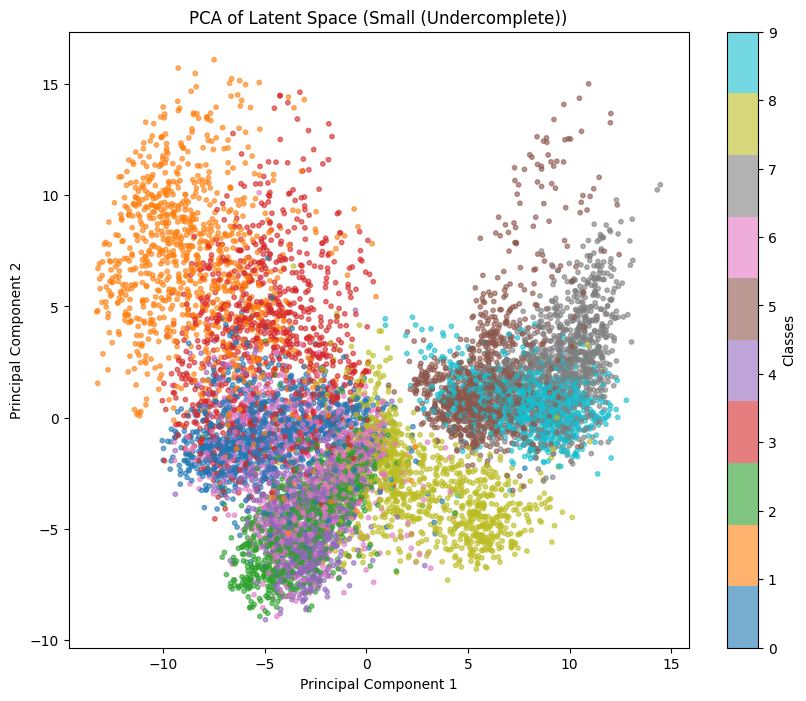

Computing PCA...


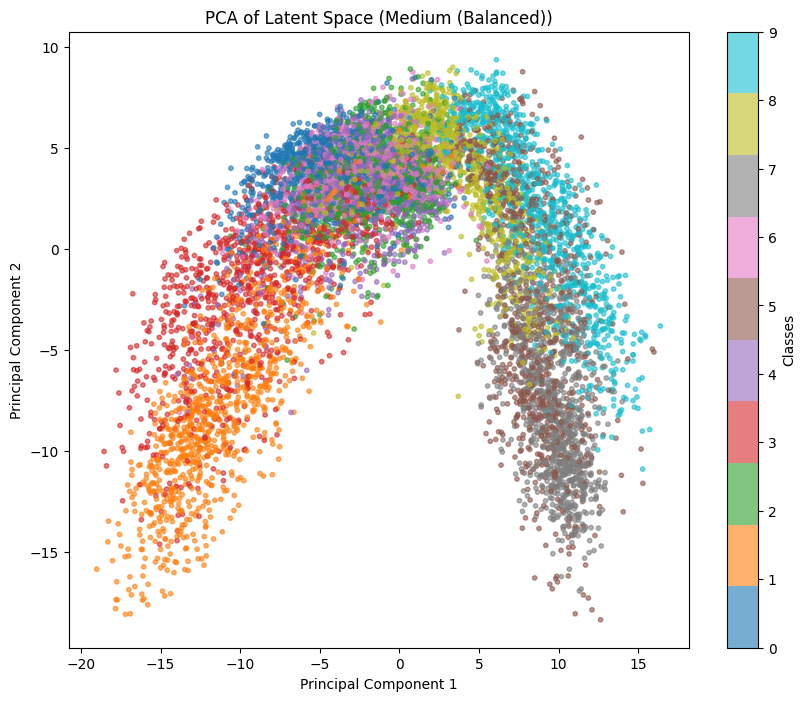

Computing PCA...


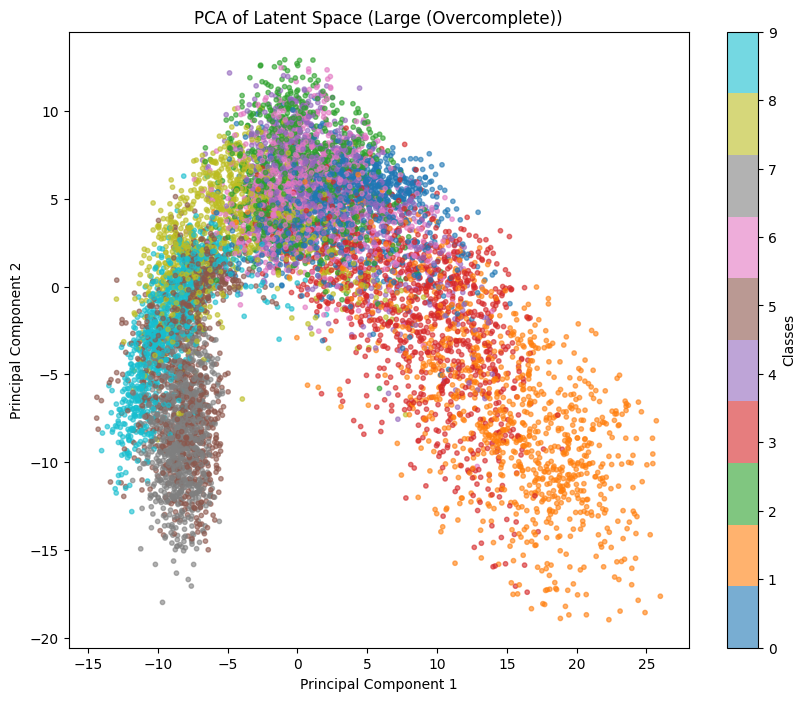

In [5]:
# Task 4 & 5: Latent Space Analysis
def extract_latent_representations(model, dataloader):
    model.eval()
    all_z = []
    all_labels = []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            _, z = model(images)
            all_z.append(z.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_z), np.concatenate(all_labels)

# We will visualize the Medium model as it's the most balanced
for name, size in latent_sizes.items():
    model = models[f"{name}"]
    z_reps, labels = extract_latent_representations(model, test_loader)

# 4.1 PCA Visualization
    print("Computing PCA...")
    pca = PCA(n_components=2)
    z_pca = pca.fit_transform(z_reps)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(z_pca[:, 0], z_pca[:, 1], c=labels, cmap='tab10', alpha=0.6, s=10)
    plt.colorbar(scatter, ticks=range(10), label='Classes')
    plt.title(f"PCA of Latent Space ({name})")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.show()


==================== Latent Size: Small (Undercomplete) ====================


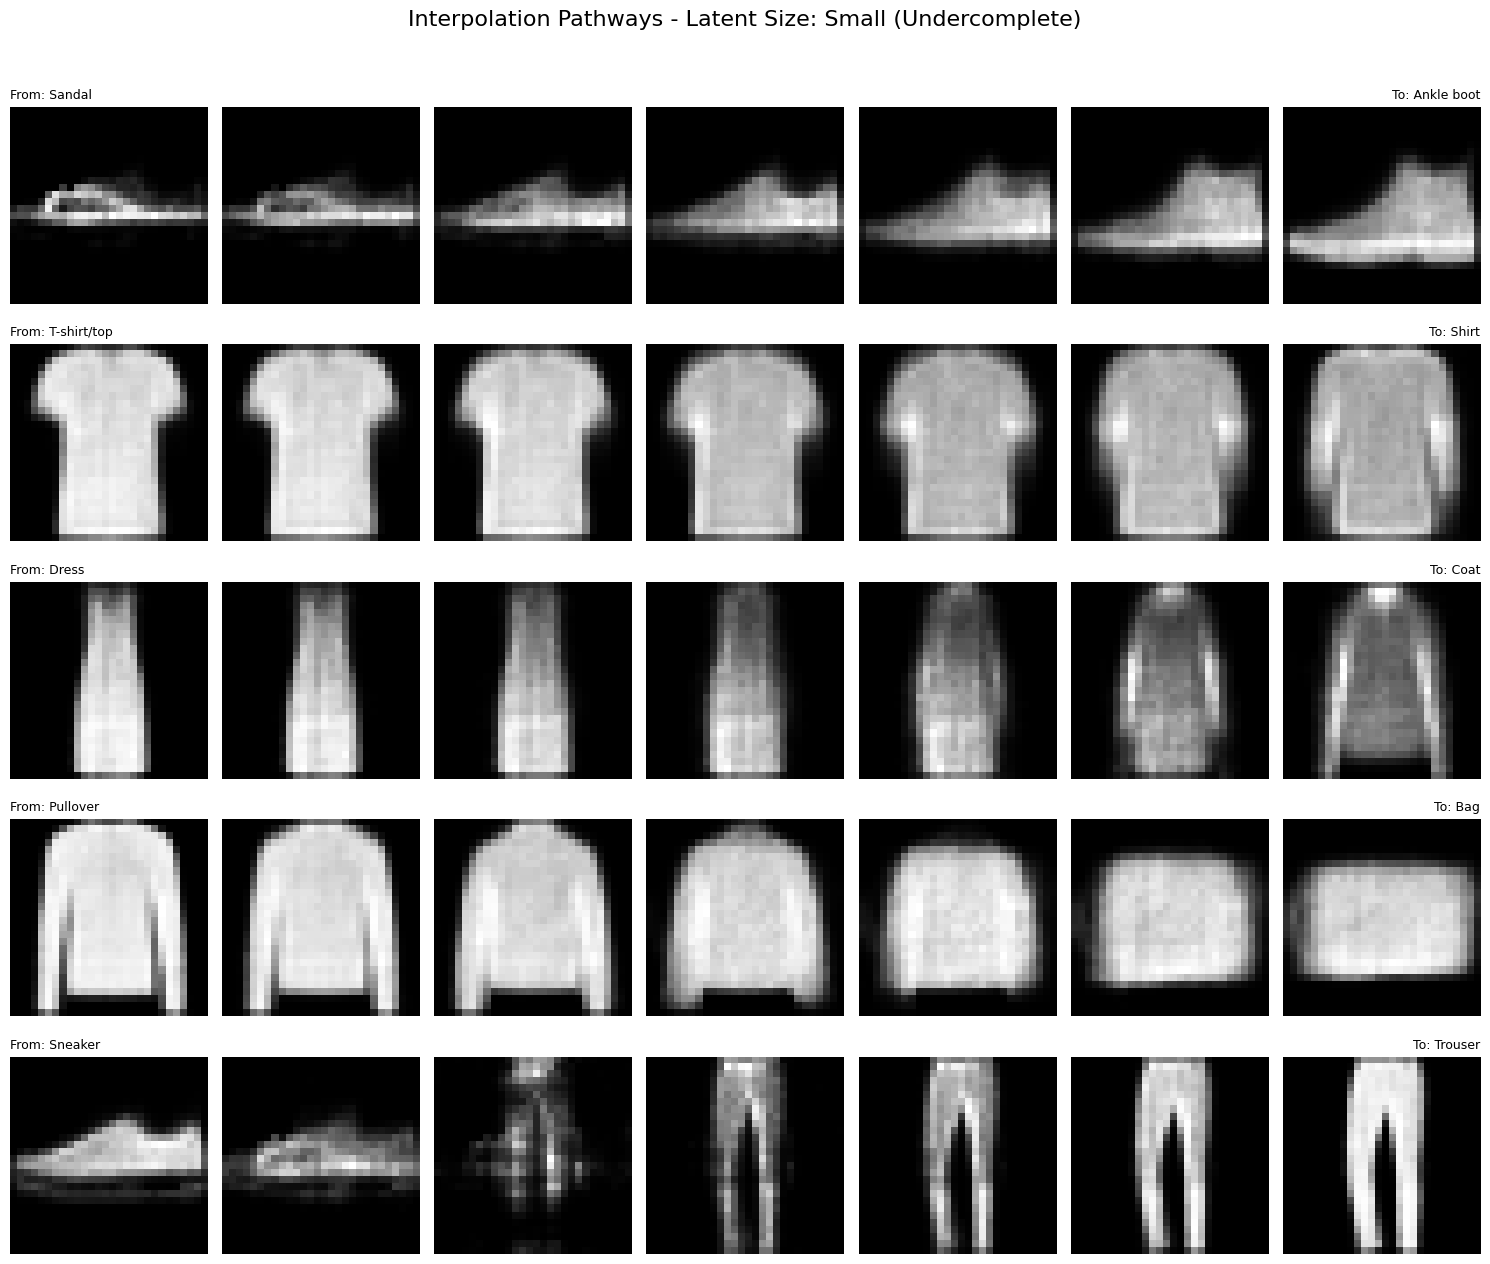


==================== Latent Size: Medium (Balanced) ====================


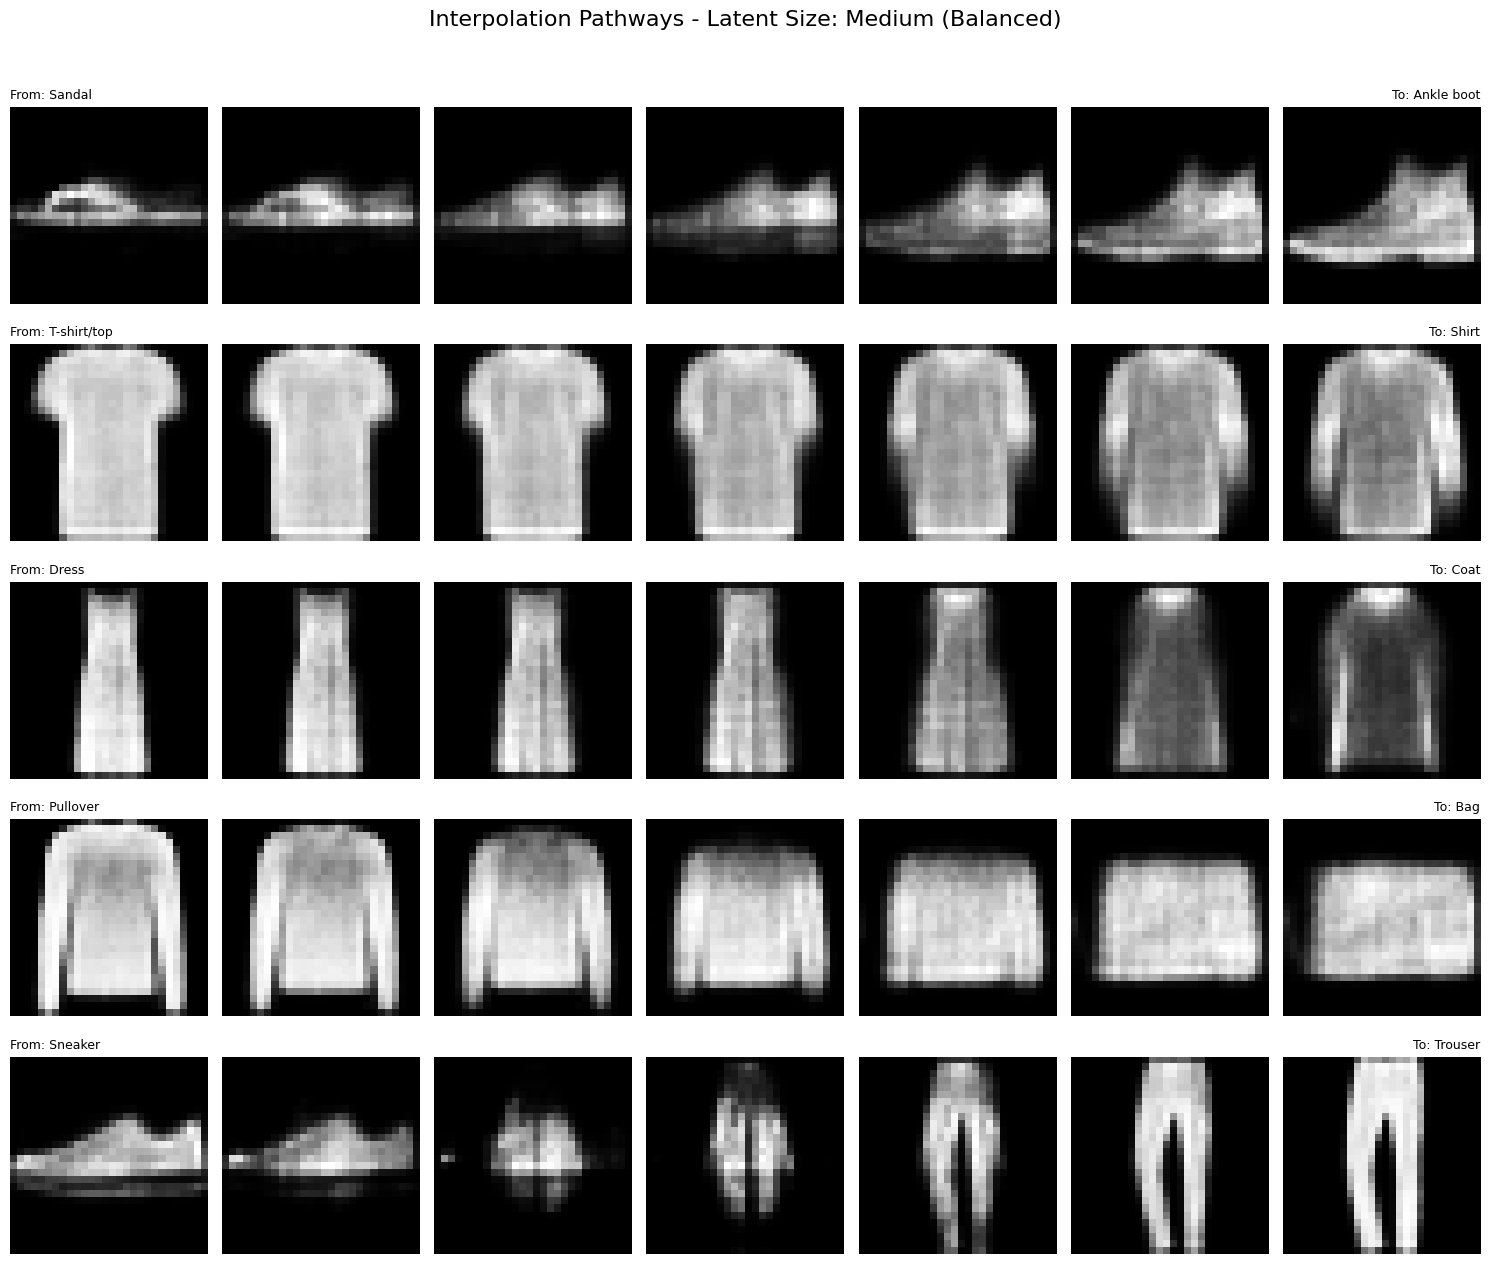


==================== Latent Size: Large (Overcomplete) ====================


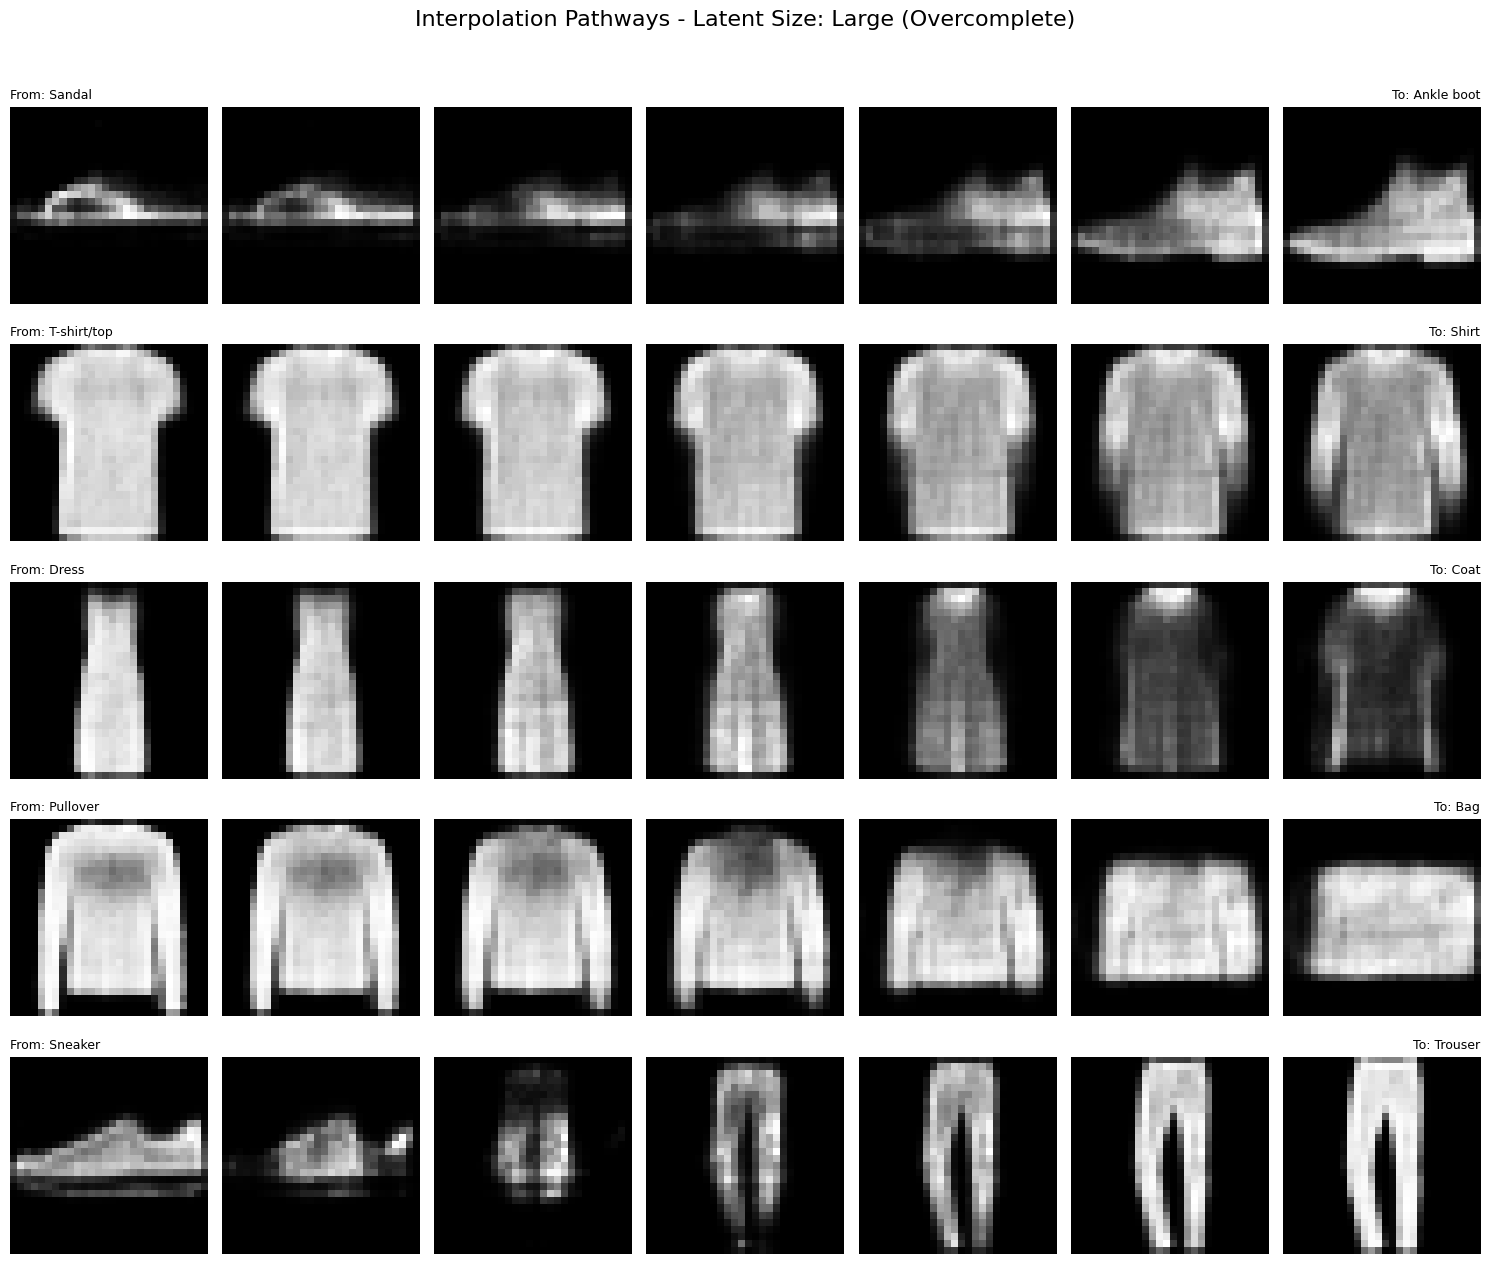

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
def get_class_indices(dataset, target_classes):
    indices = []
    found_classes = {}
    for i, (img, label) in enumerate(dataset):
        class_name = classes[label]
        if class_name in target_classes and class_name not in found_classes:
            indices.append(i)
            found_classes[class_name] = True
        if len(indices) == len(target_classes):
            break
    return indices

def run_targeted_interpolations(models, dataset, steps=7):
    # Define the 5 specific pairs requested
    pairs = [
        ("Sandal", "Ankle boot"),
        ("T-shirt/top", "Shirt"),
        ("Dress", "Coat"),
        ("Pullover", "Bag"),
        ("Sneaker", "Trouser")
    ]
    
    for name, model in models.items():
        print(f"\n{'='*20} Latent Size: {name} {'='*20}")
        fig, axes = plt.subplots(len(pairs), steps, figsize=(15, 2.5 * len(pairs)))
        model.eval()
        
        for row, (start_cls, end_cls) in enumerate(pairs):
            # Find images for these classes
            idx1 = [i for i, l in enumerate(dataset.targets) if classes[l] == start_cls][0]
            idx2 = [i for i, l in enumerate(dataset.targets) if classes[l] == end_cls][0]
            
            img1, _ = dataset[idx1]
            img2, _ = dataset[idx2]
            
            with torch.no_grad():
                _, z1 = model(img1.unsqueeze(0).to(device))
                _, z2 = model(img2.unsqueeze(0).to(device))
                
                alphas = np.linspace(0, 1, steps)
                for col, alpha in enumerate(alphas):
                    z_interp = (1 - alpha) * z1 + alpha * z2
                    recon = model.decoder(z_interp).view(28, 28).cpu()
                    
                    axes[row, col].imshow(recon, cmap='gray')
                    axes[row, col].axis('off')
                    
                    if col == 0:
                        axes[row, col].set_title(f"From: {start_cls}", loc='left', fontsize=9)
                    if col == steps - 1:
                        axes[row, col].set_title(f"To: {end_cls}", loc='right', fontsize=9)
        
        plt.suptitle(f"Interpolation Pathways - Latent Size: {name}", fontsize=16, y=1.02)
        plt.tight_layout()
        plt.show()

# Run the experiment
run_targeted_interpolations(models, test_dataset)

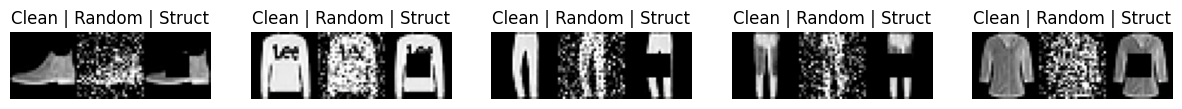

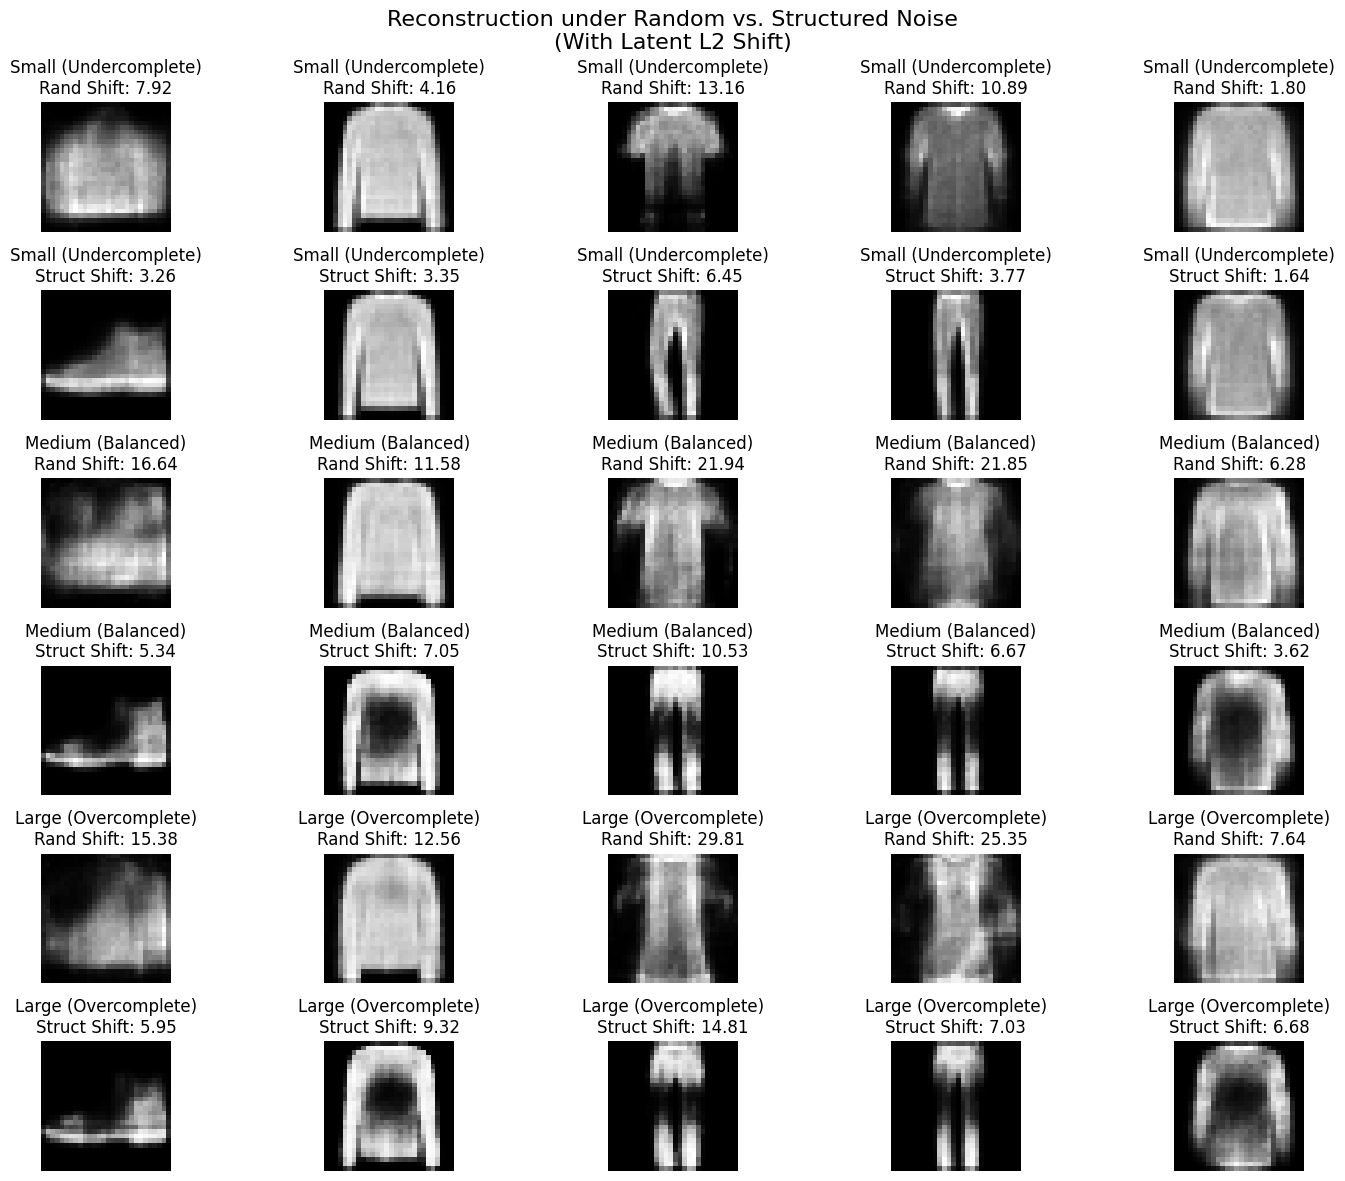

In [8]:
# Task 6: Noise Experiment & Latent Structure Comparison
import torch.nn.functional as F

def apply_random_noise(images, factor=0.4):
    noisy = images + factor * torch.randn_like(images)
    return torch.clamp(noisy, 0., 1.)

def apply_structured_noise(images):
    # Adds a 10x10 zeroed-out (black) patch to the center of the image
    noisy = images.clone()
    noisy[:, :, 9:19, 9:19] = 0.0 
    return noisy

# 1. Select 5 fixed images
test_iter = iter(test_loader)
clean_images, labels = next(test_iter)
clean_images = clean_images[:5].to(device)

# 2. Generate noisy versions
random_noisy_imgs = apply_random_noise(clean_images)
struct_noisy_imgs = apply_structured_noise(clean_images)

def analyze_noise_robustness(models, clean, rand_noisy, struct_noisy):
    fig, axes = plt.subplots(len(models) * 2, 5, figsize=(15, 4 * len(models)))
    
    row = 0
    for name, model in models.items():
        model.eval()
        with torch.no_grad():
            # Get Reconstructions and Latents
            _, z_clean = model(clean)
            
            recon_rand, z_rand = model(rand_noisy)
            recon_struct, z_struct = model(struct_noisy)
            
            # Calculate Latent Shift (L2 Distance)
            shift_rand = torch.norm(z_clean - z_rand, dim=1).cpu().numpy()
            shift_struct = torch.norm(z_clean - z_struct, dim=1).cpu().numpy()

        for i in range(5):
            # Plot Random Noise Reconstructions
            axes[row, i].imshow(recon_rand[i].cpu().squeeze(), cmap='gray')
            axes[row, i].set_title(f"{name}\nRand Shift: {shift_rand[i]:.2f}")
            axes[row, i].axis('off')
            
            # Plot Structured Noise Reconstructions
            axes[row+1, i].imshow(recon_struct[i].cpu().squeeze(), cmap='gray')
            axes[row+1, i].set_title(f"{name}\nStruct Shift: {shift_struct[i]:.2f}")
            axes[row+1, i].axis('off')
        
        row += 2
        
    plt.suptitle("Reconstruction under Random vs. Structured Noise\n(With Latent L2 Shift)", fontsize=16)
    plt.tight_layout()
    plt.show()

# Show the noisy inputs first
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    axes[i].imshow(torch.cat([clean_images[i], random_noisy_imgs[i], struct_noisy_imgs[i]], dim=2).cpu().squeeze(), cmap='gray')
    axes[i].set_title(f"Clean | Random | Struct")
    axes[i].axis('off')
plt.show()

# Run the analysis
analyze_noise_robustness(models, clean_images, random_noisy_imgs, struct_noisy_imgs)

Training Classifiers (This will take a moment)...


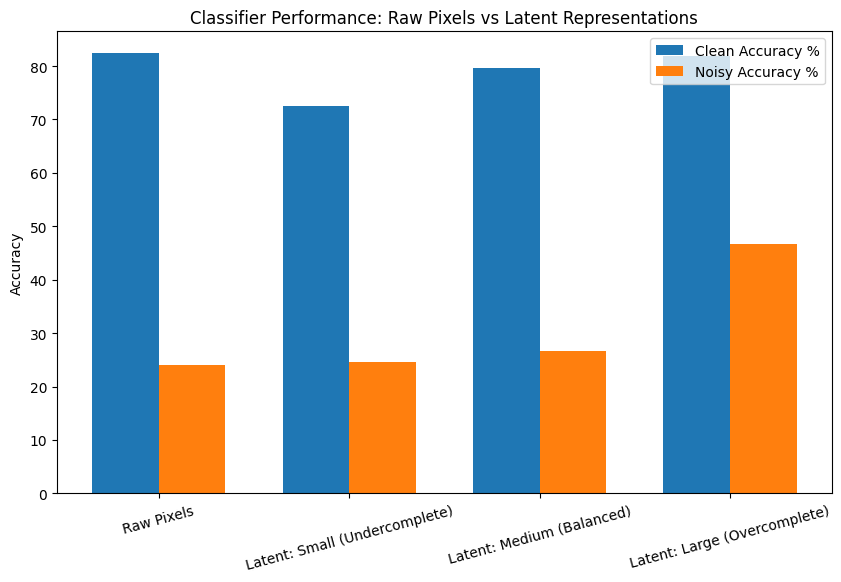

In [9]:
# Task 7: Classification Utility
class LinearClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Linear(input_dim, 10)
        
    def forward(self, x):
        return self.fc(x)

def train_eval_classifier(classifier, extract_fn, epochs=5):
    optimizer = optim.Adam(classifier.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()
    
    # Train
    classifier.train()
    for epoch in range(epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            features = extract_fn(images)
            
            optimizer.zero_grad()
            outputs = classifier(features)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
    # Evaluate on Clean and Noisy
    classifier.eval()
    correct_clean, correct_noisy, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            noisy_images = apply_random_noise(images, factor=0.5)
            #took random noisy with alpha = 0.5
            # Clean accuracy
            out_clean = classifier(extract_fn(images))
            correct_clean += (out_clean.argmax(1) == labels).sum().item()
            
            # Noisy accuracy
            out_noisy = classifier(extract_fn(noisy_images))
            correct_noisy += (out_noisy.argmax(1) == labels).sum().item()
            
            total += labels.size(0)
            
    return (correct_clean/total)*100, (correct_noisy/total)*100

print("Training Classifiers (This will take a moment)...")

results = {}

# Case A: Raw Pixels (784 dim)
raw_clf = LinearClassifier(784).to(device)
acc_c, acc_n = train_eval_classifier(raw_clf, lambda x: x.view(-1, 784))
results["Raw Pixels"] = (acc_c, acc_n)

# Case B: Latent Representations
for name, model in models.items():
    model.eval() # Freeze AE
    latent_dim = model.encoder[-1].out_features
    lat_clf = LinearClassifier(latent_dim).to(device)
    
    # Extract function: get z, detach it so gradients don't flow to AE
    def get_z(x, m=model):
        _, z = m(x)
        return z.detach()
        
    acc_c, acc_n = train_eval_classifier(lat_clf, get_z)
    results[f"Latent: {name}"] = (acc_c, acc_n)

# Plot Results
labels = list(results.keys())
clean_accs = [r[0] for r in results.values()]
noisy_accs = [r[1] for r in results.values()]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, clean_accs, width, label='Clean Accuracy %')
rects2 = ax.bar(x + width/2, noisy_accs, width, label='Noisy Accuracy %')

ax.set_ylabel('Accuracy')
ax.set_title('Classifier Performance: Raw Pixels vs Latent Representations')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.legend()
plt.show()

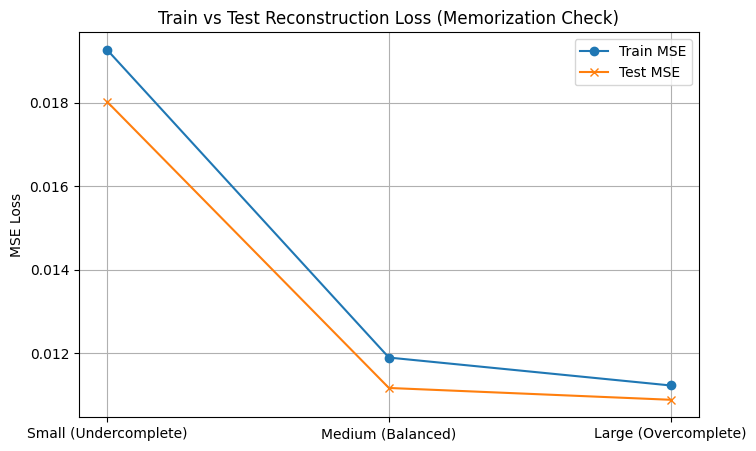

Decoding random vectors to check if the latent space is 'meaningful'...


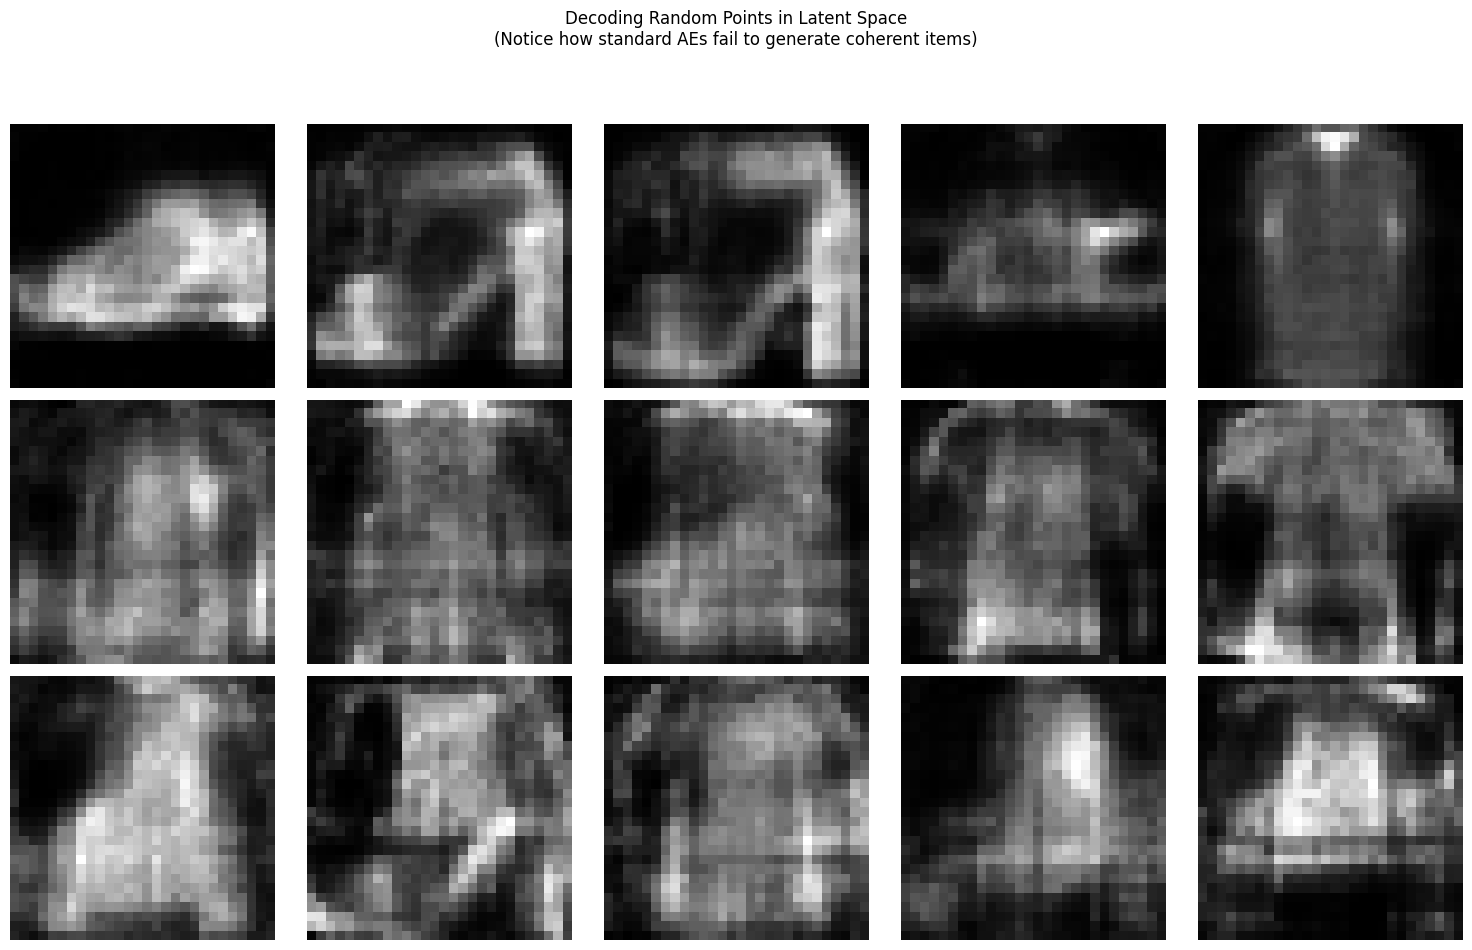

In [10]:
# Task 8: Capacity, Memorization, and Failure Modes
def evaluate_train_test_gap(models):
    gaps = {}
    criterion = nn.MSELoss()
    
    for name, model in models.items():
        model.eval()
        train_loss, test_loss = 0, 0
        
        with torch.no_grad():
            # Sample from train
            for imgs, _ in train_loader:
                imgs = imgs.to(device)
                recons, _ = model(imgs)
                train_loss += criterion(recons, imgs).item()
                break # Just evaluate one batch for speed
                
            # Sample from test
            for imgs, _ in test_loader:
                imgs = imgs.to(device)
                recons, _ = model(imgs)
                test_loss += criterion(recons, imgs).item()
                break
                
        gaps[name] = {"Train": train_loss, "Test": test_loss}
    return gaps

gaps = evaluate_train_test_gap(models)

# 1. Visualize Train vs Test Loss (Testing for Memorization)
names = list(gaps.keys())
train_mse = [gaps[n]["Train"] for n in names]
test_mse = [gaps[n]["Test"] for n in names]

plt.figure(figsize=(8, 5))
plt.plot(names, train_mse, marker='o', label='Train MSE')
plt.plot(names, test_mse, marker='x', label='Test MSE')
plt.title("Train vs Test Reconstruction Loss (Memorization Check)")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

# 2. Visualize Meaningless Latent Space (Random Decoding)
print("Decoding random vectors to check if the latent space is 'meaningful'...")
fig, axes = plt.subplots(len(models), 5, figsize=(15, 3 * len(models)))

row = 0
for name, model in models.items():
    model.eval()
    latent_dim = model.encoder[-1].out_features
    
    # Sample completely random vectors (Gaussian noise)
    random_z = torch.randn(5, latent_dim).to(device)
    
    with torch.no_grad():
        hallucinations = model.decoder(random_z).view(-1, 1, 28, 28)
        
    for i in range(5):
        axes[row, i].imshow(hallucinations[i].cpu().squeeze(), cmap='gray')
        axes[row, i].axis('off')
        if i == 0: axes[row, i].set_ylabel(name, fontsize=10)
    row += 1

plt.suptitle("Decoding Random Points in Latent Space\n(Notice how standard AEs fail to generate coherent items)", y=1.05)
plt.tight_layout()
plt.show()